In [2]:
# 라이브러리 설치
# !pip install torch torchvision torchaudio

In [3]:
# 라이브러리 로드
import torch
import torch.nn as nn
import torch.optim as optim

In [4]:
# 데이터셋을 생성
# 독립, 종속 -> 파이토치에서는 독립, 종속 변수의 데이터 타입은 Tensor로 구성
# 독립 변수 -> 2차원 데이터
# 종속 변수 -> 2차원 데이터 (sklearn에서는 1차원)
X =  torch.tensor([[1.0], [2.0], [3.0], [4.0]])
# 종속 변수는 독립 변수 데이터에서 2를 곱하고 1을 더해준 값으로 생성
Y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

In [5]:
# 선형회귀
class LinearReg(nn.Module):
    # 생성자함수
    def __init__(self):
        # self : 클래스가 생성된 메모리의 주소
        # super() : 부모 클래스의 의미 -> 상속
        super(LinearReg, self).__init__()   # 부모 클래스의 생성자 함수를 실행
        # self.linear = nn.Linear()
        # Linear()에서는 첫번째인자로는 입력 데이터(독립의 피쳐) 크기
        # 두번째 인자의 출력(종속의 피쳐)의 크기
        self.linear = nn.Linear(1, 1)
    
    # forward(self, x)
    def forward(self, x):
        return self.linear(x)

In [6]:
# 모델을 생성 -> 회귀 모델
# LinearReg 라는 클래스에서 생성자 함수에 매개변수가 self을 제외하고 존재하지 않기 때문에 클래스 생성시 인자 값을 넣지 않는다.
model = LinearReg()

In [7]:
# 손실 함수
criterion = nn.MSELoss()
# 가중치의 갱신 (경사 하강법) lr은 가중치의 변환 시 봔환 비율
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [8]:
# 500번 반복 실행하면서 Loss를 확인
for epoch in range(500):
    # 순전파
    Y_pred = model(X)
    # 손실 함수
    loss = criterion(Y_pred, Y)
    # 역전파
    optimizer.zero_grad()       #기울기 초기화
    loss.backward()             # 기울기 계산
    optimizer.step()            # 파라미터를 업데이트
    
    # 50회 마다 loss의 값을 출력
    if (epoch + 1) % 50 ==0:
        print(f'Epoch : [{epoch+1}, 500], Loss : {round(loss.item(), 4)}')

Epoch : [50, 500], Loss : 0.0057
Epoch : [100, 500], Loss : 0.0042
Epoch : [150, 500], Loss : 0.0031
Epoch : [200, 500], Loss : 0.0023
Epoch : [250, 500], Loss : 0.0017
Epoch : [300, 500], Loss : 0.0013
Epoch : [350, 500], Loss : 0.0009
Epoch : [400, 500], Loss : 0.0007
Epoch : [450, 500], Loss : 0.0005
Epoch : [500, 500], Loss : 0.0004


In [9]:
# 예측 값 확인
pred = model(X).detach()

for i in range(len(X)):
    print(f"독립 : {X[i].item()}, 종속 : {Y[i].item()}, 예측 : {pred[i].item()}")

독립 : 1.0, 종속 : 3.0, 예측 : 3.0315613746643066
독립 : 2.0, 종속 : 5.0, 예측 : 5.015293598175049
독립 : 3.0, 종속 : 7.0, 예측 : 6.999026298522949
독립 : 4.0, 종속 : 9.0, 예측 : 8.982758522033691


In [10]:
# sklearn에서 제공하는 캘리포니아 데이터를 이용하여 회귀분석
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

In [11]:
# 데이터를 로드해서 독립 종속 변수 데이터 생성
data = fetch_california_housing()

X = data['data']
Y = data['target']

print("독립 변수 데이터의 크기 : ", X.shape)
print("종속 변수 데이터의 크기 : ", Y.shape)

독립 변수 데이터의 크기 :  (20640, 8)
종속 변수 데이터의 크기 :  (20640,)


In [12]:
# 데이터를 학습, 평가 데이터로 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2,
    random_state=42
)

In [13]:
# StandardScaler를 이용하여 스케일링 -> train 데이터를 기준으로 filtering을 하고
# train, test 모두 같은 fit model에서 변환 작업 (데이터 누수 방지)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [14]:
# 총 4개의 데이터의 타입은 array형태 -> tensor 형태로 변환
X_train_sc_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_sc_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Y의 데이터들은 현재 1차원 -> 2차원 변경해서 Tensor로 변환
Y_train_tensor = torch.tensor(Y_train.reshape(-1, 1), dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.reshape(-1, 1), dtype=torch.float32)

In [15]:
# class 생성
class Reg(nn.Module):
    # 생성자 함수에서 self와의 매개변수를 하나 생성 -> nn.linear()에서 사용할 첫번째 인자 값 (입력 값의 열의 크기)
    def __init__ (self, _dim):
        super(Reg, self).__init__()
        self.linear = nn.Linear(_dim, 1)
        
    def forward(self, x):
        return self.linear(x)

In [16]:
# 모델을 생성 -> 학습 데이터의 피쳐의 개수
reg_model = Reg(X_train.shape[1])

In [17]:
# 손실 함수
loss = nn.MSELoss()
optimizer = optim.SGD(reg_model.parameters(), lr=0.01)

In [18]:
# 학습 반복 실행
for epoch in range(300):
    # 순전파
    Y_pred = reg_model(X_train_sc_tensor)
    # 손실
    loss = criterion(Y_pred, Y_train_tensor)
    # 기울기 초기화
    optimizer.zero_grad()
    # 역전파
    loss.backward()
    # 가중치 업데이트
    optimizer.step()
    # 30회 마다 loss의 변화 확인
    if (epoch + 1) % 30 == 0:
        print(f"Epoch : {epoch+1}, Loss : {round(loss.item(), 4)}")

Epoch : 30, Loss : 1.8968
Epoch : 60, Loss : 1.0298
Epoch : 90, Loss : 0.7575
Epoch : 120, Loss : 0.6647
Epoch : 150, Loss : 0.6282
Epoch : 180, Loss : 0.6102
Epoch : 210, Loss : 0.5989
Epoch : 240, Loss : 0.5904
Epoch : 270, Loss : 0.5833
Epoch : 300, Loss : 0.577


In [19]:
# 현재 모델의 학습 모드에서 평가 모드로 변환 (학습이 중지가 아니라 모드의 변환)
# eval() : 평가모드 변환
# train() : 학습모드 변환
reg_model.eval()

Reg(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

In [20]:
# 예측과 평가
# torch.nograd() -> 평가 시 gradient 계산을 비활성화 (속도 빨라짐, 메모리 소모 줄어듬)
with torch.no_grad():
    Y_pred = reg_model(X_test_sc_tensor)
    test_loss = criterion(Y_pred, Y_test_tensor)

In [21]:
# 성능 평가
# MSE, RMSE 지표 확인
rmse = np.sqrt(test_loss.item())
print("테스트 데이터의 MSE : ", round(test_loss.item(), 4))
print("테스트 데이터의 RMSE : ", round(rmse, 4))

테스트 데이터의 MSE :  0.5885
테스트 데이터의 RMSE :  0.7671


In [22]:
# 실제 갑소가 예측 값을 확인 -> 상위 10개의 데이터만 확인
for i in range(10):
    print(f"실제 값 : {Y_test[i]}, 예측 값 : {round(Y_pred[i].item(), 3)}")

실제 값 : 0.477, 예측 값 : 0.928
실제 값 : 0.458, 예측 값 : 1.625
실제 값 : 5.00001, 예측 값 : 2.324
실제 값 : 2.186, 예측 값 : 2.765
실제 값 : 2.78, 예측 값 : 2.348
실제 값 : 1.587, 예측 값 : 2.107
실제 값 : 1.982, 예측 값 : 2.715
실제 값 : 1.575, 예측 값 : 2.176
실제 값 : 3.4, 예측 값 : 2.159
실제 값 : 4.466, 예측 값 : 4.041


In [23]:
# 스탠다드 스케일링을 하지 않은 데이터를 이용하여 학습하고 예측을 출력하시오.
reg_model2 = Reg(X_train.shape[1])
# 손실 함수
criterion2 = nn.MSELoss() 
# Adam -> 적응형 학습률 기반 경사하강법
optimizer2 = optim.Adam(reg_model2.parameters(), lr=0.01)

# 학습 반복 실행
for epoch in range(300):
    # 순전파
    Y_pred2 = reg_model2(X_train_tensor)
    # 손실
    loss2 = criterion(Y_pred2, Y_train_tensor)
    # 기울기 초기화
    optimizer2.zero_grad()
    # 역전파
    loss2.backward()
    # 가중치 업데이트
    optimizer2.step()

reg_model2.eval()
with torch.no_grad():
    Y_pred2 = reg_model2(X_test_tensor)
    test_loss2 = criterion2(Y_pred2, Y_test_tensor)

rmse2 = np.sqrt(test_loss.item())
print("테스트 데이터의 MSE : ", round(test_loss2.item(), 4))
print("테스트 데이터의 RMSE : ", round(rmse2, 4))



for i in range(10):
    print(f"실제 값 : {Y_test[i]}, 예측 값 : {round(Y_pred2[i].item(), 3)}")

테스트 데이터의 MSE :  0.868
테스트 데이터의 RMSE :  0.7671
실제 값 : 0.477, 예측 값 : 1.521
실제 값 : 0.458, 예측 값 : 1.897
실제 값 : 5.00001, 예측 값 : 1.889
실제 값 : 2.186, 예측 값 : 2.488
실제 값 : 2.78, 예측 값 : 2.11
실제 값 : 1.587, 예측 값 : 2.169
실제 값 : 1.982, 예측 값 : 2.583
실제 값 : 1.575, 예측 값 : 2.256
실제 값 : 3.4, 예측 값 : 1.738
실제 값 : 4.466, 예측 값 : 3.154


In [24]:
# 파이토치를 이용한 분류 분석
# iris 데이터를 이용
from sklearn.datasets import load_iris
# 분류 검증 정확도
from sklearn.metrics import accuracy_score

In [25]:
iris = load_iris()
X = iris['data']
Y = iris['target']

In [26]:
# train, test 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [27]:
# 스탠다드스케일러를 이용한 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
# 분류 모델에서 Tensor 데이터로 변환
# 독립변수 -> float32
# 종속변수 -> long 타입으로 변경
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

In [29]:
# 모델의 정의
class IrisClass(nn.Module):
    def __init__(self):
        # 부모 클래스의 생성자 함수 실행
        super(IrisClass, self).__init__()
        # 분류 모델을 선택
        self.model = nn.Sequential(
            # Linear() -> 첫번째 인자 입력
            # 두번째 인자 값을 분류 클래스의 개수
            nn.Linear(4, 3)
        )
    
    def forward(self, x):
        return self.model(x)

In [30]:
# 모델의 생성
cls_model = IrisClass()

In [31]:
# 손실 함수 / 옵티마이저 생성
# 분류 모델의 손실 함수
criterion = nn.CrossEntropyLoss()
# 옵티마이저
optimizer = optim.Adam(cls_model.parameters(), lr=0.01)

In [32]:
# 반복 학습 시작
for epoch in range(300):
    Y_pred = cls_model(X_train_tensor)
    loss = criterion(Y_pred, Y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    
    # 30회 마다 loss를 확인
    if (epoch+1) % 30 == 0:
        print(f"Epoch : {epoch+1}, Loss : {round(loss.item(), 4)}")

Epoch : 30, Loss : 0.8161
Epoch : 60, Loss : 0.5453
Epoch : 90, Loss : 0.4437
Epoch : 120, Loss : 0.3887
Epoch : 150, Loss : 0.3512
Epoch : 180, Loss : 0.3221
Epoch : 210, Loss : 0.2979
Epoch : 240, Loss : 0.277
Epoch : 270, Loss : 0.2587
Epoch : 300, Loss : 0.2425


In [33]:
# 평가
cls_model.eval()
with torch.no_grad():
    # pred -> 예측에 대한 엔트로피 계수(높은 값의 위치가 유력)
    pred = cls_model(X_test_tensor)
    _, pred_idx = torch.max(pred, 1)
    #정확도 계산
    acc = accuracy_score(Y_test, pred_idx)
print("정확도 : ", acc)

정확도 :  1.0


In [34]:
# torch.max() : 2차원 리스트형태의 데이터에서 각 원소별 값, 위치를 반환하는 함수
torch.max(pred, 1)

torch.return_types.max(
values=tensor([1.6961, 4.1273, 4.7208, 0.7601, 1.9651, 3.3781, 0.5666, 2.2072, 1.9215,
        1.3321, 1.3106, 3.5342, 3.9695, 3.6238, 4.9058, 0.3328, 2.2588, 1.6322,
        1.0415, 2.3254, 3.8822, 0.8411, 3.7550, 2.1980, 2.5570, 2.2183, 2.6340,
        2.4479, 3.2153, 3.5128]),
indices=tensor([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2,
        2, 2, 2, 2, 0, 0]))

In [35]:
for i in range(10):
    print(f"실제 데이터 : {Y_test[i]}, 예측 데이터 : {pred_idx[i].item()}")

실제 데이터 : 1, 예측 데이터 : 1
실제 데이터 : 0, 예측 데이터 : 0
실제 데이터 : 2, 예측 데이터 : 2
실제 데이터 : 1, 예측 데이터 : 1
실제 데이터 : 1, 예측 데이터 : 1
실제 데이터 : 0, 예측 데이터 : 0
실제 데이터 : 1, 예측 데이터 : 1
실제 데이터 : 2, 예측 데이터 : 2
실제 데이터 : 1, 예측 데이터 : 1
실제 데이터 : 1, 예측 데이터 : 1


## 문제

In [36]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [37]:
df = pd.read_csv("../data/bodyPerformance.csv")

obj_cols = df.select_dtypes('object').columns.tolist()

for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].values)

In [38]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [39]:
df['class'].value_counts()

class
2    3349
3    3349
0    3348
1    3347
Name: count, dtype: int64

In [40]:
X = df.drop('class', axis=1).values
Y = df['class'].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [41]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

In [42]:
# # 모델의 정의
# class BodyClass(nn.Module):
#     def __init__(self, _dim):
#         super(BodyClass, self).__init__()
#         self.model = nn.Sequential(
#             nn.Linear(_dim, 4)
#         )
    
#     def forward(self, x):
#         return self.model(x)

In [48]:
# 모델 정의
class BodyClass(nn.Module):
    def __init__(self, _dim):
        # _dim : 입력 데이터의 피쳐의 개수를 받아오기 위한 매개변수
        super(BodyClass, self).__init__()
        # Sequential() -> 여러개의 층을 순서대로 실행
        self.model = nn.Sequential(
            nn.Linear(_dim, _dim*3),        # 11차원의 입력데이터, 22차원의 출력데이터 생성
            nn.ReLU(),
            nn.Linear(_dim * 3, _dim * 2),
            nn.ReLU(),
            nn.Linear(_dim * 2, 4)
        )
    
    def forward(self, x):
        return self.model(x)

In [49]:
body_model = BodyClass(X_train_tensor.shape[1])

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(body_model.parameters(), lr=0.01)

In [51]:
# 반복 학습 시작
for epoch in range(200):
    Y_pred = body_model(X_train_tensor)
    loss = criterion(Y_pred, Y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    
    # 30회 마다 loss를 확인
    if (epoch+1) % 20 == 0:
        print(f"Epoch : {epoch+1}, Loss : {round(loss.item(), 4)}")

Epoch : 20, Loss : 0.8871
Epoch : 40, Loss : 0.8105
Epoch : 60, Loss : 0.7671
Epoch : 80, Loss : 0.6976
Epoch : 100, Loss : 0.6345
Epoch : 120, Loss : 0.6039
Epoch : 140, Loss : 0.5908
Epoch : 160, Loss : 0.5818
Epoch : 180, Loss : 0.5739
Epoch : 200, Loss : 0.5668


In [52]:
body_model.eval()
with torch.no_grad():
    pred = body_model(X_test_tensor)
    _, pred_idx = torch.max(pred, 1)
    acc = accuracy_score(Y_test, pred_idx)
print("정확도 : ", acc)

정확도 :  0.7502799552071668


In [53]:
# 비선형 활성화 함수 비교

import matplotlib.pyplot as plt

# sim 데이터를 하나 생성
x = torch.linspace(-3, 3, 200).unsqueeze(1)
y = torch.sin(x)

In [55]:
linear_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Linear(16, 1)
)

In [56]:
relu_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [57]:
loss = nn.MSELoss()

opt1 = optim.Adam(linear_model.parameters(), lr=0.01)
opt2 = optim.Adam(relu_model.parameters(), lr=0.01)

In [58]:
# 반복 학습
for epoch in range(3000):
    # 선형 모델
    pred1 = linear_model(x)
    loss1 = loss(pred1, y)
    opt1.zero_grad()
    loss1.backward()
    opt1.step()
    
    # 비선형 모델
    pred2 = relu_model(x)
    loss2  = loss(pred2, y)
    opt2.zero_grad()
    loss2.backward()
    opt2.step()

In [59]:
# 예측 결과
linear_pred = linear_model(x).detach()
relu_pred = relu_model(x).detach()

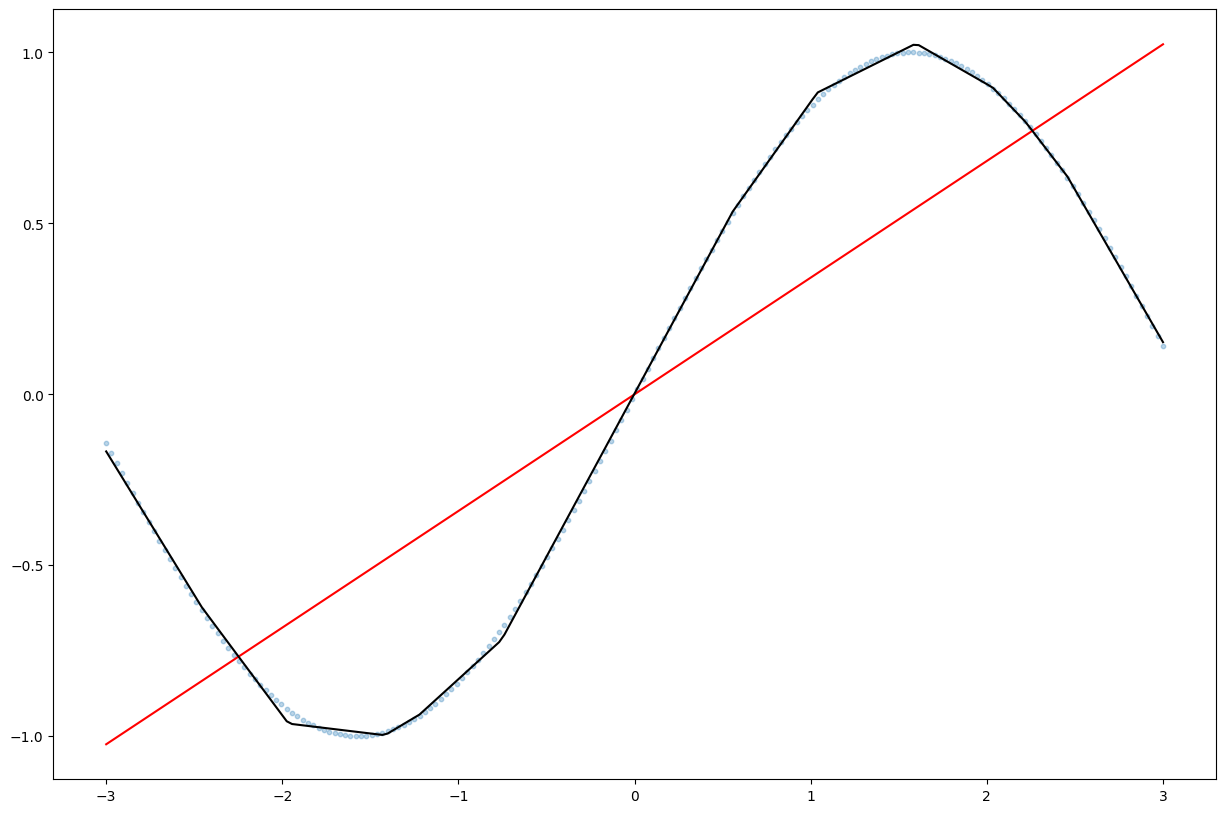

In [61]:
# 시각화
plt.figure(figsize=(15, 10))

# 원본 데이터
plt.scatter(x, y, s=10, alpha=0.3, label='Origin Data')
# 선형 모델 예측 값 -> 라인 그래프
plt.plot(x, linear_pred, color='red')
# 비선형 모델 예측 값 -> 라인그래프
plt.plot(x, relu_pred, color='black')